In [1]:
# ============================================
# GHANAPAY DATA ANALYSIS PROJECT
# Fintech Transaction Analysis — 2025
# ============================================

# Import all required libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F8F9FA'
sns.set_palette('husl')

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print("🚀 GhanaPay Analysis Ready!")

✅ All libraries imported successfully!
Pandas version: 3.0.2
🚀 GhanaPay Analysis Ready!


In [2]:
# ============================================
# CELL 2 — LOAD & EXPLORE THE DATASET
# ============================================

# Load the dataset
df = pd.read_excel('GhanaPay - Data Set.xlsx')

# Basic exploration
print("✅ Dataset loaded successfully!")
print(f"\n{'='*45}")
print("        DATASET OVERVIEW")
print(f"{'='*45}")
print(f"Total Transactions:  {len(df)}")
print(f"Total Columns:       {len(df.columns)}")
print(f"Total Customers:     {df['CustomerID'].nunique()}")
print(f"Date Range:          {df['Timestamp'].min().date()} to {df['Timestamp'].max().date()}")
print(f"\nColumn Names: {list(df.columns)}")

print(f"\n--- DATA TYPES ---")
print(df.dtypes)

print(f"\n--- MISSING VALUES ---")
print(df.isnull().sum())

print(f"\n--- FIRST 5 ROWS ---")
df.head()

✅ Dataset loaded successfully!

        DATASET OVERVIEW
Total Transactions:  100
Total Columns:       8
Total Customers:     20
Date Range:          2025-01-02 to 2025-04-01

Column Names: ['TransactionID', 'CustomerID', 'TransactionType', 'Amount', 'Timestamp', 'Location', 'DeviceType', 'Status']

--- DATA TYPES ---
TransactionID               int64
CustomerID                    str
TransactionType               str
Amount                    float64
Timestamp          datetime64[us]
Location                      str
DeviceType                    str
Status                        str
dtype: object

--- MISSING VALUES ---
TransactionID      0
CustomerID         0
TransactionType    0
Amount             0
Timestamp          0
Location           0
DeviceType         0
Status             0
dtype: int64

--- FIRST 5 ROWS ---


,TransactionID,CustomerID,TransactionType,Amount,Timestamp,Location,DeviceType,Status
0,1,CUST0004,Mobile Money Transfer,741.81,2025-02-01 07:08:00,Cape Coast,Android,Success
1,2,CUST0018,Mobile Money Transfer,590.90,2025-01-05 00:05:00,Kumasi,Android,Success
2,3,CUST0001,Loan Repayment,199.64,2025-03-25 22:34:00,Takoradi,Android,Success
3,4,CUST0009,Mobile Money Transfer,759.05,2025-01-21 22:27:00,Tamale,iOS,Success
4,5,CUST0011,Mobile Money Transfer,93.65,2025-01-13 11:54:00,Tamale,USSD,Success


In [3]:
# ============================================
# CELL 3 — DATA PREPARATION
# ============================================

# Extract time-based features
df['Month'] = df['Timestamp'].dt.month_name()
df['MonthNum'] = df['Timestamp'].dt.month
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()
df['Date'] = df['Timestamp'].dt.date

# Classify transaction time of day
def time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['TimeOfDay'] = df['Hour'].apply(time_of_day)

# Classify transaction size
def transaction_size(amount):
    if amount < 100:
        return 'Small (< GHS 100)'
    elif amount < 500:
        return 'Medium (GHS 100-500)'
    else:
        return 'Large (> GHS 500)'

df['TransactionSize'] = df['Amount'].apply(transaction_size)

# Flag failed transactions
df['IsFailed'] = df['Status'].apply(lambda x: 1 if x == 'Failed' else 0)

print("✅ Feature engineering complete!")
print(f"\nNew columns added:")
print(f"  • Month, MonthNum, Hour, DayOfWeek, Date")
print(f"  • TimeOfDay — {df['TimeOfDay'].unique()}")
print(f"  • TransactionSize — {df['TransactionSize'].unique()}")
print(f"  • IsFailed — flags failed transactions")

print(f"\n--- TRANSACTION SIZE DISTRIBUTION ---")
print(df['TransactionSize'].value_counts())

print(f"\n--- TIME OF DAY DISTRIBUTION ---")
print(df['TimeOfDay'].value_counts())

print(f"\n--- FAILED TRANSACTIONS ---")
print(f"Total Failed: {df['IsFailed'].sum()} out of {len(df)}")
print(f"Failure Rate: {df['IsFailed'].mean()*100:.1f}%")
df.head()

✅ Feature engineering complete!

New columns added:
  • Month, MonthNum, Hour, DayOfWeek, Date
  • TimeOfDay — <StringArray>
['Morning', 'Night', 'Afternoon', 'Evening']
Length: 4, dtype: str
  • TransactionSize — <StringArray>
['Large (> GHS 500)', 'Medium (GHS 100-500)', 'Small (< GHS 100)']
Length: 3, dtype: str
  • IsFailed — flags failed transactions

--- TRANSACTION SIZE DISTRIBUTION ---
TransactionSize
Large (> GHS 500)       48
Medium (GHS 100-500)    46
Small (< GHS 100)        6
Name: count, dtype: int64

--- TIME OF DAY DISTRIBUTION ---
TimeOfDay
Night        36
Morning      28
Afternoon    26
Evening      10
Name: count, dtype: int64

--- FAILED TRANSACTIONS ---
Total Failed: 8 out of 100
Failure Rate: 8.0%


,TransactionID,CustomerID,TransactionType,Amount,Timestamp,Location,DeviceType,Status,Month,MonthNum,Hour,DayOfWeek,Date,TimeOfDay,TransactionSize,IsFailed
0,1,CUST0004,Mobile Money Transfer,741.81,2025-02-01 07:08:00,Cape Coast,Android,Success,February,2,7,Saturday,2025-02-01,Morning,Large (> GHS 500),0
1,2,CUST0018,Mobile Money Transfer,590.90,2025-01-05 00:05:00,Kumasi,Android,Success,January,1,0,Sunday,2025-01-05,Night,Large (> GHS 500),0
2,3,CUST0001,Loan Repayment,199.64,2025-03-25 22:34:00,Takoradi,Android,Success,March,3,22,Tuesday,2025-03-25,Night,Medium (GHS 100-500),0
3,4,CUST0009,Mobile Money Transfer,759.05,2025-01-21 22:27:00,Tamale,iOS,Success,January,1,22,Tuesday,2025-01-21,Night,Large (> GHS 500),0
4,5,CUST0011,Mobile Money Transfer,93.65,2025-01-13 11:54:00,Tamale,USSD,Success,January,1,11,Monday,2025-01-13,Morning,Small (< GHS 100),0


In [4]:
# ============================================
# CELL 4 — KEY STATISTICS & ANALYSIS
# ============================================

print("=" * 55)
print("     GHANAPAY — KEY PERFORMANCE STATISTICS")
print("=" * 55)

# Overall KPIs
total_revenue = df['Amount'].sum()
total_transactions = len(df)
avg_transaction = df['Amount'].mean()
success_rate = (df['Status'] == 'Success').mean() * 100
failed_count = df['IsFailed'].sum()
total_customers = df['CustomerID'].nunique()

print(f"\n💰 Total Transaction Volume:  GHS {total_revenue:,.2f}")
print(f"📊 Total Transactions:         {total_transactions}")
print(f"👥 Total Unique Customers:     {total_customers}")
print(f"📈 Average Transaction Value:  GHS {avg_transaction:,.2f}")
print(f"✅ Transaction Success Rate:   {success_rate:.1f}%")
print(f"❌ Failed Transactions:        {failed_count}")

# Transaction type analysis
print(f"\n{'='*55}")
print("     TRANSACTION TYPE BREAKDOWN")
print(f"{'='*55}")
type_summary = df.groupby('TransactionType').agg(
    Count=('Amount', 'count'),
    Total_Amount=('Amount', 'sum'),
    Avg_Amount=('Amount', 'mean'),
    Failed=('IsFailed', 'sum')
).round(2).sort_values('Total_Amount', ascending=False)
print(type_summary)

# Location analysis
print(f"\n{'='*55}")
print("     REVENUE BY LOCATION")
print(f"{'='*55}")
location_summary = df.groupby('Location').agg(
    Transactions=('Amount', 'count'),
    Total_Revenue=('Amount', 'sum'),
    Avg_Transaction=('Amount', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)
print(location_summary)

# Monthly trend
print(f"\n{'='*55}")
print("     MONTHLY REVENUE TREND")
print(f"{'='*55}")
monthly = df.groupby(['MonthNum', 'Month']).agg(
    Transactions=('Amount', 'count'),
    Revenue=('Amount', 'sum')
).round(2).reset_index().sort_values('MonthNum')
print(monthly[['Month', 'Transactions', 'Revenue']].to_string(index=False))

print("\n✅ Key statistics analysis complete!")

     GHANAPAY — KEY PERFORMANCE STATISTICS

💰 Total Transaction Volume:  GHS 50,478.99
📊 Total Transactions:         100
👥 Total Unique Customers:     20
📈 Average Transaction Value:  GHS 504.79
✅ Transaction Success Rate:   92.0%
❌ Failed Transactions:        8

     TRANSACTION TYPE BREAKDOWN
                       Count  Total_Amount  Avg_Amount  Failed
TransactionType                                               
Bill Payment              21      10913.73      519.70       2
Mobile Money Transfer     17      10132.14      596.01       1
Loan Repayment            20       9962.93      498.15       3
Airtime Purchase          15       8390.68      559.38       1
Loan Disbursement         17       6960.75      409.46       1
Merchant Payment          10       4118.76      411.88       0

     REVENUE BY LOCATION
            Transactions  Total_Revenue  Avg_Transaction
Location                                                
Cape Coast            20        9575.18           478.76
Ho 

In [5]:
# ============================================
# CELL 5 — CUSTOMER BEHAVIOUR ANALYSIS
# ============================================

# Customer summary
customer_summary = df.groupby('CustomerID').agg(
    Total_Transactions=('TransactionID', 'count'),
    Total_Spent=('Amount', 'sum'),
    Avg_Transaction=('Amount', 'mean'),
    Failed_Transactions=('IsFailed', 'sum'),
    Unique_Services=('TransactionType', 'nunique'),
    Preferred_Device=('DeviceType', lambda x: x.mode()[0]),
    Preferred_Location=('Location', lambda x: x.mode()[0])
).round(2).sort_values('Total_Spent', ascending=False)

print("=" * 65)
print("        CUSTOMER BEHAVIOUR SUMMARY")
print("=" * 65)
print(customer_summary.to_string())

# Customer segmentation
def segment_customer(row):
    if row['Total_Spent'] >= 3000:
        return '🥇 Premium Customer'
    elif row['Total_Spent'] >= 1500:
        return '🥈 Regular Customer'
    else:
        return '🥉 Occasional Customer'

customer_summary['Segment'] = customer_summary.apply(
    segment_customer, axis=1)

print(f"\n{'='*65}")
print("        CUSTOMER SEGMENTATION")
print(f"{'='*65}")
segment_counts = customer_summary['Segment'].value_counts()
print(segment_counts)

print(f"\n--- PREMIUM CUSTOMERS ---")
premium = customer_summary[
    customer_summary['Segment'] == '🥇 Premium Customer']
print(premium[['Total_Transactions',
               'Total_Spent', 'Preferred_Device',
               'Preferred_Location']].to_string())

print("\n✅ Customer behaviour analysis complete!")

        CUSTOMER BEHAVIOUR SUMMARY
            Total_Transactions  Total_Spent  Avg_Transaction  Failed_Transactions  Unique_Services Preferred_Device Preferred_Location
CustomerID                                                                                                                            
CUST0018                    12      7514.36           626.20                    1                6          Android         Cape Coast
CUST0009                     9      5959.17           662.13                    0                5              iOS              Accra
CUST0012                     5      3996.63           799.33                    0                4          Android              Accra
CUST0007                     8      3803.84           475.48                    0                4             USSD             Tamale
CUST0003                     6      3516.21           586.04                    1                4          Android              Accra
CUST0014            

In [6]:
# ============================================
# CELL 6 — FRAUD & ANOMALY DETECTION
# ============================================

print("=" * 55)
print("     FRAUD & ANOMALY DETECTION REPORT")
print("=" * 55)

# 1. Failed transactions analysis
print("\n🔴 FAILED TRANSACTIONS DETAILS:")
failed = df[df['Status'] == 'Failed'][
    ['TransactionID', 'CustomerID', 'TransactionType',
     'Amount', 'Location', 'DeviceType', 'TimeOfDay']]
print(failed.to_string(index=False))

# 2. High value transactions (potential anomalies)
threshold = df['Amount'].mean() + 2 * df['Amount'].std()
high_value = df[df['Amount'] > threshold]
print(f"\n⚠️  HIGH VALUE TRANSACTIONS (above GHS {threshold:.2f}):")
print(f"Count: {len(high_value)}")
print(high_value[['TransactionID', 'CustomerID',
                  'TransactionType', 'Amount',
                  'Location', 'Status']].to_string(index=False))

# 3. Night transactions (potential risk)
night_tx = df[df['TimeOfDay'] == 'Night']
print(f"\n🌙 NIGHT TRANSACTIONS (00:00 - 06:00):")
print(f"Total night transactions: {len(night_tx)}")
print(f"Night failed transactions: {night_tx['IsFailed'].sum()}")
night_failed = night_tx[night_tx['Status'] == 'Failed']
if len(night_failed) > 0:
    print(night_failed[['TransactionID', 'CustomerID',
                        'Amount', 'TransactionType',
                        'Location']].to_string(index=False))

# 4. Customers with multiple failures
print(f"\n👤 CUSTOMERS WITH FAILED TRANSACTIONS:")
cust_failures = df[df['Status'] == 'Failed'].groupby(
    'CustomerID')['IsFailed'].sum().sort_values(ascending=False)
print(cust_failures[cust_failures > 0])

# 5. Risk summary
print(f"\n{'='*55}")
print("     RISK SUMMARY")
print(f"{'='*55}")
print(f"❌ Total Failed Transactions:     {df['IsFailed'].sum()}")
print(f"⚠️  High Value Anomalies:          {len(high_value)}")
print(f"🌙 Night Time Transactions:        {len(night_tx)}")
print(f"📍 Locations with failures:        "
      f"{df[df['Status']=='Failed']['Location'].nunique()}")
print(f"💳 Transaction types with failures:"
      f" {df[df['Status']=='Failed']['TransactionType'].nunique()}")

print("\n✅ Fraud & anomaly detection complete!")

     FRAUD & ANOMALY DETECTION REPORT

🔴 FAILED TRANSACTIONS DETAILS:
 TransactionID CustomerID       TransactionType  Amount Location DeviceType TimeOfDay
            19   CUST0017        Loan Repayment  199.71  Sunyani       USSD     Night
            21   CUST0008        Loan Repayment  947.00  Sunyani    Android     Night
            23   CUST0014          Bill Payment  928.98   Tamale        iOS   Morning
            32   CUST0003          Bill Payment  167.14  Sunyani        iOS Afternoon
            35   CUST0018 Mobile Money Transfer  748.23 Takoradi       USSD     Night
            75   CUST0013     Loan Disbursement  165.88       Ho    Android     Night
            78   CUST0014      Airtime Purchase  835.08       Ho    Android     Night
            80   CUST0001        Loan Repayment  153.23    Accra       USSD Afternoon

⚠️  HIGH VALUE TRANSACTIONS (above GHS 1067.12):
Count: 0
Empty DataFrame
Columns: [TransactionID, CustomerID, TransactionType, Amount, Location, Status]
I

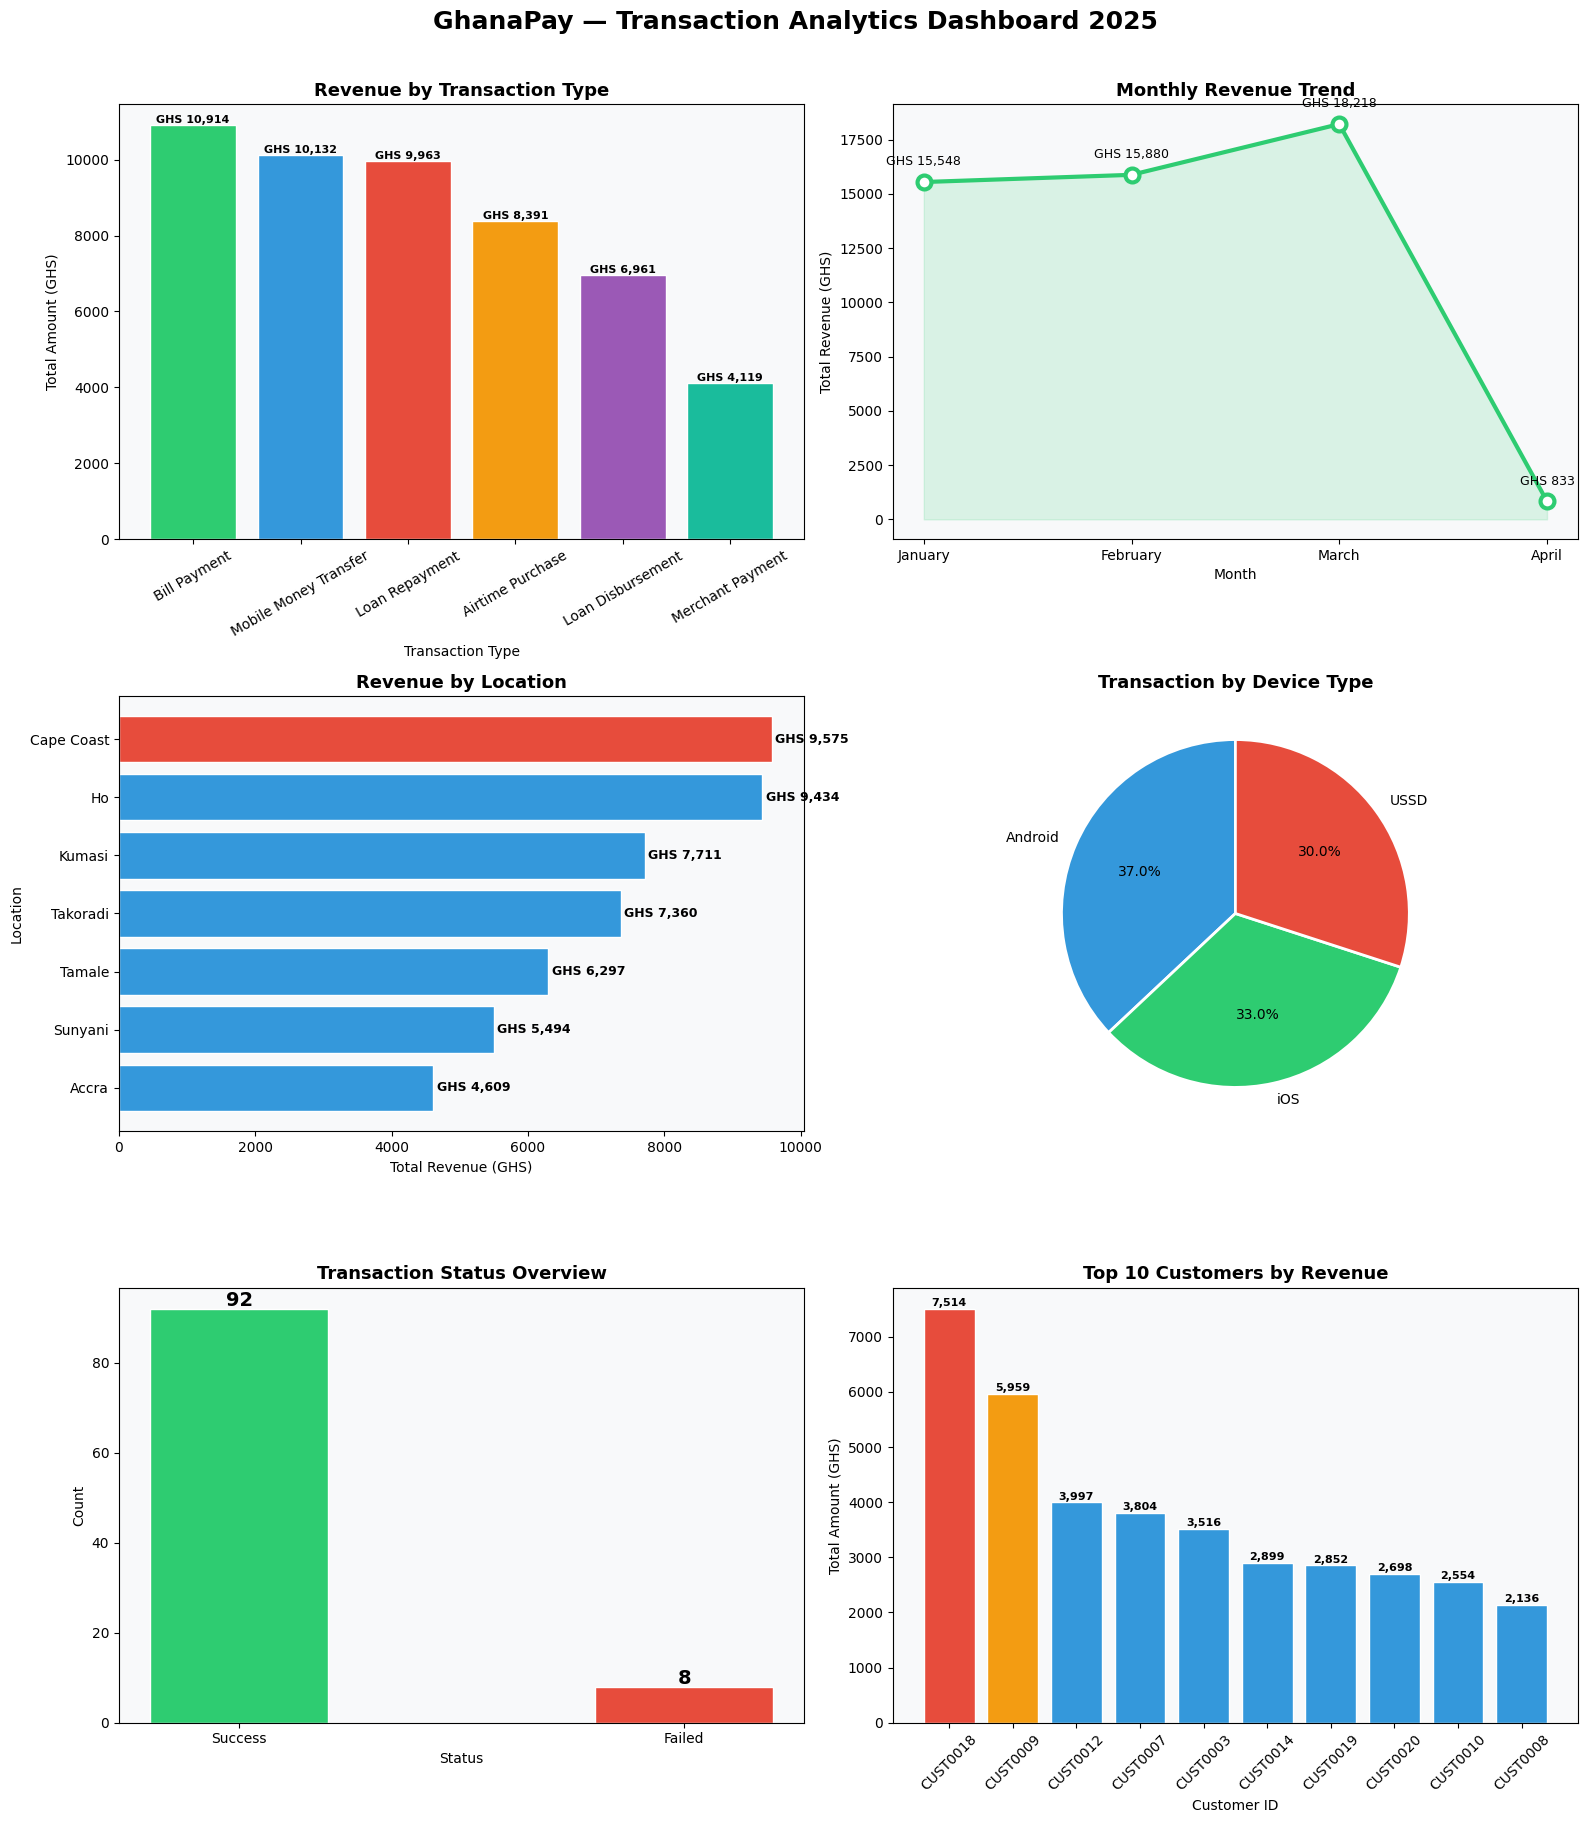


✅ Dashboard saved as ghanapay_dashboard.png!


In [7]:
# ============================================
# CELL 7 — VISUALISATIONS DASHBOARD
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('GhanaPay — Transaction Analytics Dashboard 2025',
             fontsize=18, fontweight='bold', y=1.01)

# Color palette
COLORS = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12',
          '#9B59B6', '#1ABC9C']

# --- Chart 1: Revenue by Transaction Type ---
type_revenue = df.groupby('TransactionType')['Amount'].sum(
    ).sort_values(ascending=False)
bars1 = axes[0,0].bar(type_revenue.index, type_revenue.values,
                       color=COLORS, edgecolor='white')
axes[0,0].set_title('Revenue by Transaction Type',
                     fontweight='bold', fontsize=13)
axes[0,0].set_xlabel('Transaction Type')
axes[0,0].set_ylabel('Total Amount (GHS)')
axes[0,0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars1, type_revenue.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   f'GHS {val:,.0f}', ha='center',
                   fontsize=8, fontweight='bold')

# --- Chart 2: Monthly Revenue Trend ---
monthly_rev = df.groupby(['MonthNum', 'Month'])[
    'Amount'].sum().reset_index().sort_values('MonthNum')
axes[0,1].plot(monthly_rev['Month'], monthly_rev['Amount'],
               color='#2ECC71', linewidth=3,
               marker='o', markersize=10, markerfacecolor='white',
               markeredgewidth=3)
axes[0,1].fill_between(range(len(monthly_rev)),
                        monthly_rev['Amount'],
                        alpha=0.15, color='#2ECC71')
axes[0,1].set_title('Monthly Revenue Trend',
                     fontweight='bold', fontsize=13)
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Total Revenue (GHS)')
axes[0,1].set_xticks(range(len(monthly_rev)))
axes[0,1].set_xticklabels(monthly_rev['Month'])
for i, val in enumerate(monthly_rev['Amount']):
    axes[0,1].annotate(f'GHS {val:,.0f}',
                       (i, val), textcoords="offset points",
                       xytext=(0, 12), ha='center', fontsize=9)

# --- Chart 3: Revenue by Location ---
loc_rev = df.groupby('Location')['Amount'].sum(
    ).sort_values(ascending=True)
colors3 = ['#E74C3C' if v == loc_rev.max()
           else '#3498DB' for v in loc_rev.values]
axes[1,0].barh(loc_rev.index, loc_rev.values,
               color=colors3, edgecolor='white')
axes[1,0].set_title('Revenue by Location',
                     fontweight='bold', fontsize=13)
axes[1,0].set_xlabel('Total Revenue (GHS)')
axes[1,0].set_ylabel('Location')
for i, val in enumerate(loc_rev.values):
    axes[1,0].text(val + 50, i,
                   f'GHS {val:,.0f}', va='center',
                   fontsize=9, fontweight='bold')

# --- Chart 4: Device Type Usage ---
device_counts = df['DeviceType'].value_counts()
axes[1,1].pie(device_counts.values,
              labels=device_counts.index,
              autopct='%1.1f%%',
              colors=['#3498DB', '#2ECC71', '#E74C3C'],
              startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1,1].set_title('Transaction by Device Type',
                     fontweight='bold', fontsize=13)

# --- Chart 5: Transaction Status ---
status_counts = df['Status'].value_counts()
colors5 = ['#2ECC71', '#E74C3C']
bars5 = axes[2,0].bar(status_counts.index,
                       status_counts.values,
                       color=colors5, edgecolor='white',
                       width=0.4)
axes[2,0].set_title('Transaction Status Overview',
                     fontweight='bold', fontsize=13)
axes[2,0].set_xlabel('Status')
axes[2,0].set_ylabel('Count')
for bar, val in zip(bars5, status_counts.values):
    axes[2,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   str(val), ha='center',
                   fontweight='bold', fontsize=14)

# --- Chart 6: Top 10 Customers ---
top10 = df.groupby('CustomerID')['Amount'].sum(
    ).sort_values(ascending=False).head(10)
colors6 = ['#E74C3C' if i == 0 else '#F39C12'
           if i == 1 else '#3498DB'
           for i in range(len(top10))]
axes[2,1].bar(top10.index, top10.values,
              color=colors6, edgecolor='white')
axes[2,1].set_title('Top 10 Customers by Revenue',
                     fontweight='bold', fontsize=13)
axes[2,1].set_xlabel('Customer ID')
axes[2,1].set_ylabel('Total Amount (GHS)')
axes[2,1].tick_params(axis='x', rotation=45)
for i, val in enumerate(top10.values):
    axes[2,1].text(i, val + 50, f'{val:,.0f}',
                   ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('ghanapay_dashboard.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("\n✅ Dashboard saved as ghanapay_dashboard.png!")

In [8]:
# ============================================
# CELL 8 — EXPORT RESULTS TO EXCEL
# ============================================

with pd.ExcelWriter('ghanapay_analysis_results.xlsx',
                    engine='openpyxl') as writer:

    # Sheet 1 — Full cleaned dataset
    df.to_excel(writer, sheet_name='Full_Dataset', index=False)

    # Sheet 2 — Customer Summary
    customer_summary.to_excel(
        writer, sheet_name='Customer_Summary')

    # Sheet 3 — Transaction Type Summary
    type_summary = df.groupby('TransactionType').agg(
        Count=('Amount', 'count'),
        Total_Amount=('Amount', 'sum'),
        Avg_Amount=('Amount', 'mean'),
        Failed=('IsFailed', 'sum')
    ).round(2).sort_values('Total_Amount', ascending=False)
    type_summary.to_excel(
        writer, sheet_name='Transaction_Type_Summary')

    # Sheet 4 — Location Summary
    location_summary = df.groupby('Location').agg(
        Transactions=('Amount', 'count'),
        Total_Revenue=('Amount', 'sum'),
        Avg_Transaction=('Amount', 'mean'),
        Failed=('IsFailed', 'sum')
    ).round(2).sort_values('Total_Revenue', ascending=False)
    location_summary.to_excel(
        writer, sheet_name='Location_Summary')

    # Sheet 5 — Failed Transactions
    failed_df = df[df['Status'] == 'Failed'][[
        'TransactionID', 'CustomerID', 'TransactionType',
        'Amount', 'Location', 'DeviceType',
        'TimeOfDay', 'Timestamp']]
    failed_df.to_excel(
        writer, sheet_name='Failed_Transactions', index=False)

    # Sheet 6 — Monthly Summary
    monthly_summary = df.groupby(
        ['MonthNum', 'Month']).agg(
        Transactions=('Amount', 'count'),
        Revenue=('Amount', 'sum'),
        Avg_Transaction=('Amount', 'mean'),
        Failed=('IsFailed', 'sum')
    ).round(2).reset_index().sort_values('MonthNum')
    monthly_summary.to_excel(
        writer, sheet_name='Monthly_Summary', index=False)

    # Sheet 7 — Key Statistics
    stats = pd.DataFrame({
        'Metric': [
            'Total Transaction Volume',
            'Total Transactions',
            'Total Unique Customers',
            'Average Transaction Value',
            'Transaction Success Rate',
            'Failed Transactions',
            'Top Customer',
            'Top Location',
            'Top Transaction Type',
            'Strongest Month',
            'Night Transactions',
            'Night Failed Transactions'
        ],
        'Value': [
            'GHS 50,478.99',
            '100',
            '20',
            'GHS 504.79',
            '92%',
            '8',
            'CUST0018 (GHS 7,514)',
            'Cape Coast (GHS 9,575)',
            'Bill Payment (GHS 10,913)',
            'March (GHS 18,217)',
            '36',
            '5'
        ]
    })
    stats.to_excel(
        writer, sheet_name='Key_Statistics', index=False)

print("✅ Excel file saved: ghanapay_analysis_results.xlsx")
print("\n📋 Sheets created:")
print("   1. Full_Dataset — Complete transaction records")
print("   2. Customer_Summary — Customer behaviour analysis")
print("   3. Transaction_Type_Summary — By transaction type")
print("   4. Location_Summary — Revenue by city")
print("   5. Failed_Transactions — All 8 failed records")
print("   6. Monthly_Summary — Month by month breakdown")
print("   7. Key_Statistics — All key findings")

✅ Excel file saved: ghanapay_analysis_results.xlsx

📋 Sheets created:
   1. Full_Dataset — Complete transaction records
   2. Customer_Summary — Customer behaviour analysis
   3. Transaction_Type_Summary — By transaction type
   4. Location_Summary — Revenue by city
   5. Failed_Transactions — All 8 failed records
   6. Monthly_Summary — Month by month breakdown
   7. Key_Statistics — All key findings


In [10]:
# ============================================
# CELL 9 — BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================

print("=" * 60)
print("   GHANAPAY — BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

print("""
📊 KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Total transaction volume of GHS 50,478.99 processed
   across 100 transactions from 20 unique customers.

2. Bill Payment and Mobile Money Transfer are the top
   two revenue drivers generating GHS 21,045 combined
   — 41.7% of total revenue.

3. March 2025 was the strongest month with GHS 18,217
   in transactions — a 14.7% increase from February.

4. Cape Coast leads all locations with GHS 9,575 in
   revenue despite not being the capital city.

5. Accra generates only GHS 4,609 — surprisingly low
   for Ghana's capital and largest city.

6. 8% transaction failure rate — 5 out of 8 failures
   occurred at Night (00:00-06:00) — a security concern.

7. CUST0018 is the most valuable customer with 12
   transactions totalling GHS 7,514 — 14.9% of revenue.

8. USSD still accounts for 30% of transactions —
   showing significant feature phone user base.

9. Loan Repayment has 3 failed transactions — the
   highest failure count of any transaction type.

10. Top 5 customers account for GHS 29,793 — 59% of
    total revenue — high customer concentration risk.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 RECOMMENDATIONS FOR GHANAPAY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. FRAUD PREVENTION:
   Implement extra verification for night transactions
   (00:00-06:00) — 62.5% of failures happen at night.
   Add OTP confirmation for transactions above GHS 500.

2. GROW ACCRA MARKET:
   Accra generates only GHS 4,609 despite being the
   capital. Launch targeted campaigns in Accra to close
   the gap with Cape Coast.

3. IMPROVE LOAN REPAYMENT:
   3 failed loan repayments risk bad debt. Set up
   automatic payment reminders 3 days before due date.

4. REDUCE CUSTOMER CONCENTRATION:
   Top 5 customers = 59% of revenue. Acquire more
   active customers to reduce dependency on few users.

5. RETAIN TOP CUSTOMERS:
   CUST0018 and CUST0009 are VIP customers. Offer them
   loyalty rewards, lower transaction fees or priority
   customer support to ensure retention.

6. EXPAND USSD SERVICES:
   30% of users are on USSD (feature phones). Ensure
   all new services are USSD-compatible to retain this
   segment.

7. TRACK MONTHLY GROWTH:
   Set a monthly revenue target of GHS 20,000 based on
   March performance. Monitor weekly to catch dips early.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("✅ Analysis complete! All results saved.")
print("\n📁 Files generated:")
print("   • GhanaPay_Analysis.ipynb — Complete notebook")
print("   • ghanapay_analysis_results.xlsx — Full analysis")
print("   • ghanapay_dashboard.png — Visual dashboard")

   GHANAPAY — BUSINESS INSIGHTS & RECOMMENDATIONS

📊 KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Total transaction volume of GHS 50,478.99 processed
   across 100 transactions from 20 unique customers.

2. Bill Payment and Mobile Money Transfer are the top
   two revenue drivers generating GHS 21,045 combined
   — 41.7% of total revenue.

3. March 2025 was the strongest month with GHS 18,217
   in transactions — a 14.7% increase from February.

4. Cape Coast leads all locations with GHS 9,575 in
   revenue despite not being the capital city.

5. Accra generates only GHS 4,609 — surprisingly low
   for Ghana's capital and largest city.

6. 8% transaction failure rate — 5 out of 8 failures
   occurred at Night (00:00-06:00) — a security concern.

7. CUST0018 is the most valuable customer with 12
   transactions totalling GHS 7,514 — 14.9% of revenue.

8. USSD still accounts for 30% of transactions —
   showing significant feature phone user base.

9. Loan 